Load required libraries and test installation

In [157]:
from pathlib import Path
from scipy import sparse
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy.external as sce
import harmonypy as hm

import scvi

print("scanpy:", sc.__version__)
print("anndata:", ad.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scvi-tools:", scvi.__version__)


scanpy: 1.11.5
anndata: 0.12.16
pandas: 2.3.3
numpy: 2.4.6
scvi-tools: 1.4.2


In [158]:
PROJECT_DIR = Path("./cardiac_regen_practical")
DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURE_DIR = RESULTS_DIR / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

mouse_file = DATA_DIR / "3ae58a8e-a64e-44b5-94c6-af55c88e02d3.h5ad"
zebrafish_file = DATA_DIR / "sce_ZF_sampleIntegration_2022-02-02.h5ad"

Load AnnData objects

In [194]:
mouse = sc.read_h5ad(mouse_file)
zebrafish = sc.read_h5ad(zebrafish_file)
print("loaded datasets")

# store count layer
mouse.layers["counts"] = mouse.raw.X.copy()
zebrafish.layers["counts"] = zebrafish.raw.X.copy()

loaded datasets

mouse.raw.X
dtype: float32
contains NaN: False
contains negative: False
integer-like: True
max fractional: 0.0
min: 1.0
max: 30059.0
first 20: [3. 4. 1. 1. 2. 2. 3. 1. 1. 1. 2. 1. 1. 5. 2. 2. 1. 3. 1. 6.]

zebrafish.raw.X
dtype: float32
contains NaN: False
contains negative: False
integer-like: True
max fractional: 0.0
min: 1.0
max: 11062.0
first 20: [5. 1. 1. 1. 5. 1. 1. 6. 1. 4. 1. 2. 1. 9. 2. 2. 1. 3. 2. 4.]


Inspect the AnnData structure

Before analysing the data, we should inspect the structure of each object

AnnData object strcuture:
adata.X        expression matrix: cells × genes
adata.obs      cell metadata
adata.var      gene metadata
adata.obsm     multi-dimensional cell embeddings
adata.layers   alternative expression matrices
adata.uns      unstructured analysis results

In [160]:
# Inspect object dimensions
print("Mouse shape:", mouse.shape)
print("Zebrafish shape:", zebrafish.shape)

print("\nMouse AnnData object:")
print(mouse)

print("\nZebrafish AnnData object:")
print(zebrafish)

# Inspect cell metadata columns
print("Mouse obs columns:")
print(mouse.obs.columns.tolist())

print("\nZebrafish obs columns:")
print(zebrafish.obs.columns.tolist())

# Inspect gene metadata columns
print("Mouse var columns:")
print(mouse.var.columns.tolist())

print("\nZebrafish var columns:")
print(zebrafish.var.columns.tolist())

Mouse shape: (194315, 22728)
Zebrafish shape: (70783, 23326)

Mouse AnnData object:
AnnData object with n_obs × n_vars = 194315 × 22728
    obs: 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'suspension_type', 'tissue_ontology_term_id', 'day', 'surgery', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'is_pre_analysis', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_UMAP'
    layers: 'counts'

Zebrafish AnnData object:
AnnData object with n_obs × n_vars = 70783 × 23326
    obs: 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'deve

The zebrafish data only has cluster assignments, not cell identities, so these must be assigned

Shared genes: 23326
Cell_type
Fibroblasts (const.)              1000
T-cells                           1000
Cardiomyocytes (Ventricle)        1000
Smooth muscle cells               1000
Endocardium (Atrium)              1000
Endocardium (Ventricle)           1000
Endocardium (frzb)                1000
Macrophages                       1000
Epicardium (Atrium)                953
Bl.ves.EC (plvapb)                 933
Cardiomyocytes (ttn.2)             922
Fibroblasts (col12a1a)             886
Cardiomyocytes (Atrium)            876
Epicardium (Ventricle)             815
Fibroblasts (col11a1a)             611
Valve fibroblasts                  491
Fibroblasts (nppc)                 480
Fibroblasts (cfd)                  430
Neutrophils                        423
Bl.ves.EC (lyve1)                  369
Fibroblasts (cxcl12a)              364
Bl.ves.EC (apnln)                  338
Perivascular cells                 224
Fibroblasts (spock3)               213
Fibroblasts (proliferating)       

/Users/yep25yan/miniforge3/envs/cardiac-integration/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


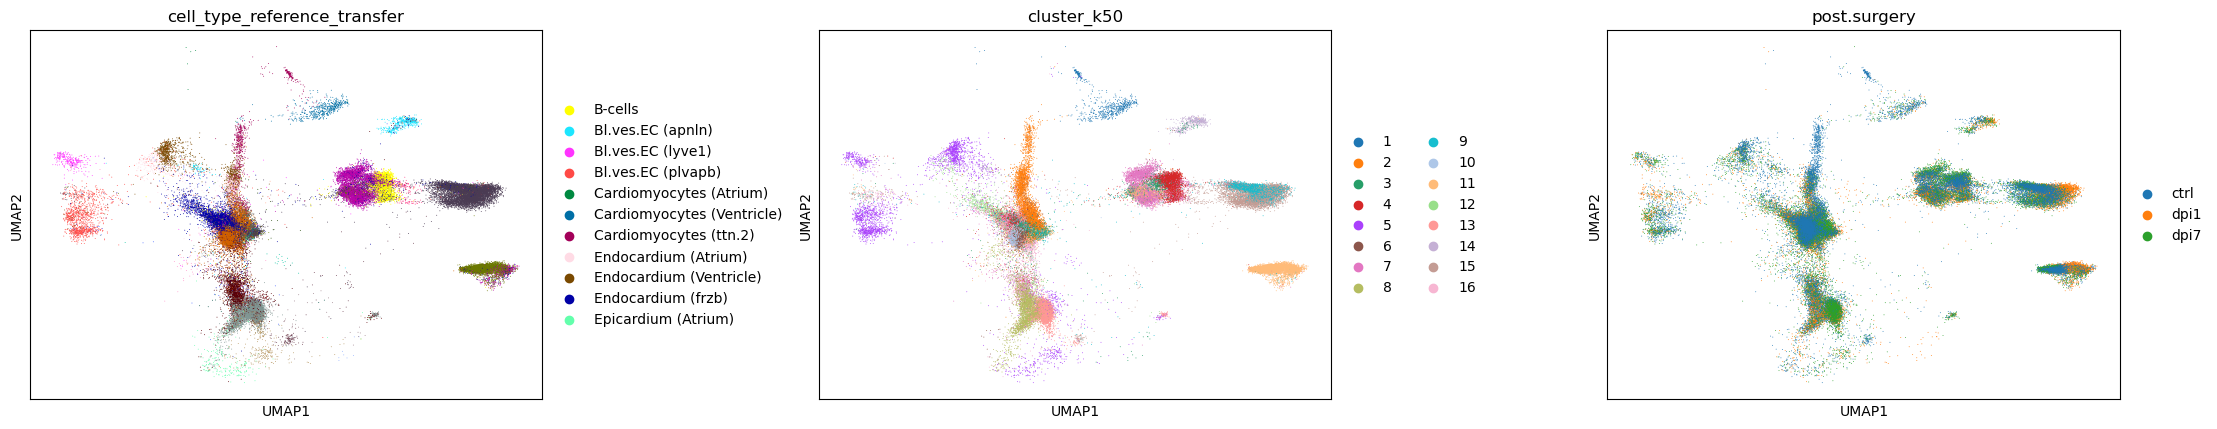

cell_type
Valve fibroblasts              14482
Macrophages                    10295
Endocardium (frzb)              9528
Fibroblasts (cxcl12a)           8858
Neutrophils                     6341
T-cells                         5930
Fibroblasts (const.)            3580
B-cells                         2615
Bl.ves.EC (plvapb)              1538
Endocardium (Ventricle)         1363
Myelin cells                    1261
Endocardium (Atrium)            1257
Cardiomyocytes (ttn.2)           737
Bl.ves.EC (apnln)                576
Cardiomyocytes (Ventricle)       485
Epicardium (Ventricle)           455
Bl.ves.EC (lyve1)                345
Epicardium (Atrium)              263
Fibroblasts (mpeg1.1)            164
Perivascular cells               163
Monocytes                        158
Smooth muscle cells              138
Fibroblasts (spock3)             101
Fibroblasts (col12a1a)            48
Fibroblasts (nppc)                33
Fibroblasts (cfd)                 26
Fibroblasts (proliferating) 

In [195]:
# load zebrafish reference data
zebrafish_ref = sc.read_h5ad(DATA_DIR/"adata.h5ad")

# Reference-based label transfer requires both datasets to contain the same genes.
zebrafish_ref.var_names = zebrafish_ref.var["Accession"]
shared_genes = zebrafish_ref.var_names.intersection(zebrafish.var_names)

print("Shared genes:", len(shared_genes))

zfish_ref_shared = zebrafish_ref[:, shared_genes].copy()
zfish_query_shared = zebrafish[:, shared_genes].copy()

# downsample the reference to speed up training
max_cells_per_label = 1000

reference_indices = []

for label, group in zfish_ref_shared.obs.groupby("Cell_type"):
    if group.shape[0] > max_cells_per_label:
        chosen = group.sample(max_cells_per_label, random_state=0).index
    else:
        chosen = group.index

    reference_indices.extend(chosen)

zfish_ref_small = zfish_ref_shared[reference_indices].copy()

print(zfish_ref_small.obs["Cell_type"].value_counts())
print(zfish_ref_small)

# preprocess the datasets through Scanpy
def preprocess_for_label_transfer(adata):
    adata = adata.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata

zfish_ref_small = preprocess_for_label_transfer(zfish_ref_small)
zfish_query_shared = preprocess_for_label_transfer(zfish_query_shared)

sc.pp.highly_variable_genes(
    zfish_ref_small,
    n_top_genes=3000,
    flavor="seurat"
)

sc.pp.pca(
    zfish_ref_small,
    use_highly_variable=True,
    n_comps=30
)

sc.pp.neighbors(zfish_ref_small)
sc.tl.umap(zfish_ref_small)

# perform ultra-lightweight reference mapping
sc.tl.ingest(
    zfish_query_shared,
    zfish_ref_small,
    obs="Cell_type"
)

# Store transferred labels
zfish_query_shared.obs["cell_type_reference_transfer"] = (
    zfish_query_shared.obs["Cell_type"].astype(str)
)

zfish_query_shared.obs["cell_type_reference_transfer"].value_counts()

# visualise transferred labels
sc.pl.umap(
    zfish_query_shared,
    color=[
        "cell_type_reference_transfer",
        "cluster_k50",
        "post.surgery",
    ],
    wspace=0.4
)

# Add transferred labels back to the original zebrafish object
zebrafish.obs["cell_type"] = (
    zfish_query_shared.obs["cell_type_reference_transfer"]
    .reindex(zebrafish.obs_names)
)

zebrafish.obs["cell_type"].value_counts(dropna=False)

The mouse and zebrafish AnnData objects use different metadata column names.

A shared set of columns based on the variables we want to integrate is needed:
- `species`
- `sample_id`
- `condition`
- `timepoint`
- `cell_type_label`

In [196]:
# Add species labels
mouse.obs["species"] = "mouse"
zebrafish.obs["species"] = "zebrafish"

# Create a shared sample identifier
mouse.obs["sample_id"] = mouse.obs["donor_id"].astype(str)
zebrafish.obs["sample_id"] = zebrafish.obs["donor_id"].astype(str)

# Add condition identifier
mouse.obs["condition"] = mouse.obs["surgery"].astype(str)
zebrafish.obs["condition"] = zebrafish.obs["post.surgery"].astype(str)

# Add timepoint covariate
mouse.obs["timepoint"] = mouse.obs["day"].astype(str)
zebrafish.obs["timepoint"] = zebrafish.obs["post.surgery"].astype(str)

# Add cell_type labels
mouse.obs["cell_type_label"] = mouse.obs["cell_type"].astype(str)
zebrafish.obs["cell_type_label"] = zebrafish.obs["cell_type"].astype(str)

# confirm that both objects contain the same core metadata columns
shared_columns = [
    "species",
    "sample_id",
    "condition",
    "timepoint",
    "cell_type_label",
]

print("Mouse metadata:")
display(mouse.obs[shared_columns].head())
mouse.obs[shared_columns] = mouse.obs[shared_columns].astype("category")

print("Zebrafish metadata:")
display(zebrafish.obs[shared_columns].head())
zebrafish.obs[shared_columns] = zebrafish.obs[shared_columns].astype("category")

Mouse metadata:


,species,sample_id,condition,timepoint,cell_type_label
blood_sham_d30_run1.2,mouse,mm_donors_I.J,sham,d30,T cell
blood_sham_d30_run1.3,mouse,mm_donors_I.J,sham,d30,T cell
blood_sham_d30_run1.4,mouse,mm_donors_I.J,sham,d30,T cell
blood_sham_d30_run1.5,mouse,mm_donors_I.J,sham,d30,T cell
blood_sham_d30_run1.7,mouse,mm_donors_I.J,sham,d30,T cell


Zebrafish metadata:


,species,sample_id,condition,timepoint,cell_type_label
AAACCCAAGAGGGCGA_1dpi.Heart.1,zebrafish,zf_Heart_injury_dpi1,dpi1,dpi1,Valve fibroblasts
AAACCCAAGGCTCCCA_1dpi.Heart.1,zebrafish,zf_Heart_injury_dpi1,dpi1,dpi1,Endocardium (Ventricle)
AAACCCACAATGCAGG_1dpi.Heart.1,zebrafish,zf_Heart_injury_dpi1,dpi1,dpi1,Neutrophils
AAACCCACATCCTTCG_1dpi.Heart.1,zebrafish,zf_Heart_injury_dpi1,dpi1,dpi1,Macrophages
AAACCCATCCCTCTCC_1dpi.Heart.1,zebrafish,zf_Heart_injury_dpi1,dpi1,dpi1,Valve fibroblasts


Perform ortholog mapping and combine AnnData objects into a single object

In [197]:
# set var_names to gene symbols
mouse.var_names = mouse.var["feature_name"].astype(str).str.strip()
zebrafish.var_names = zebrafish.var["Symbol"].astype(str).str.strip()

mouse.var_names_make_unique()
zebrafish.var_names_make_unique()

# find one-to-one orthologs for cross-species comparison
orthologs = pd.read_csv(DATA_DIR/"mouse_orthos_2026.06.14.tsv", sep="\t", header=1)

mouse_counts = orthologs["Mouse Symbol"].value_counts()
zfish_counts = orthologs["ZFIN Symbol"].value_counts()

one_to_one = orthologs[
    orthologs["Mouse Symbol"].isin(mouse_counts[mouse_counts == 1].index)
    & orthologs["ZFIN Symbol"].isin(zfish_counts[zfish_counts == 1].index)
].copy()

print("All one-to-one ortholog pairs:", orthologs.shape[0])

orthologs_present = one_to_one[
    one_to_one["Mouse Symbol"].isin(mouse.var_names)
    & one_to_one["ZFIN Symbol"].isin(zebrafish.var_names)
].copy()

orthologs_present = orthologs_present.drop_duplicates(
    subset=["Mouse Symbol", "ZFIN Symbol"]
)

print("Ortholog pairs present in both datasets:", orthologs_present.shape[0])

# replace gene names with orthologs
mouse_genes = orthologs_present["Mouse Symbol"].values
zebrafish_genes = orthologs_present["ZFIN Symbol"].values

mouse_orth = mouse[:, mouse_genes].copy()
zebrafish_orth = zebrafish[:, zebrafish_genes].copy()

zebrafish_orth.var["zebrafish_symbol"] = zebrafish_orth.var_names.astype(str)
zebrafish_orth.var["mouse_ortholog"] = mouse_genes
mouse_orth.var["mouse_symbol"] = mouse_orth.var_names.astype(str)

zebrafish_orth.var_names = mouse_genes
zebrafish_orth = zebrafish_orth[:, mouse_orth.var_names].copy()

print("Mouse ortholog object:", mouse_orth.shape)
print("Zebrafish ortholog object:", zebrafish_orth.shape)
print("Gene names identical:", mouse_orth.var_names.equals(zebrafish_orth.var_names))

# keep only shared columns
mouse_orth.obs = mouse_orth.obs[shared_columns].copy()
zebrafish_orth.obs = zebrafish_orth.obs[shared_columns].copy()

# combine datasets 
combined = ad.concat(
    [mouse_orth, zebrafish_orth],
    label="dataset",
    keys=["mouse", "zebrafish"],
    join="inner",
    merge="first",
)

combined.obs_names_make_unique()

All one-to-one ortholog pairs: 31807
Ortholog pairs present in both datasets: 1268
Mouse ortholog object: (194315, 1268)
Zebrafish ortholog object: (70783, 1268)
Gene names identical: True


Different datasets often have different granularities of cell types (e.g. Lymphocyte vs CD4+ T Cell), so it is helpful to harmonise them for visualisation purposes

In [198]:
# harmonise obs
cell_type_harmonisation = {
    # Lymphoid
    "B cell": "B cell",
    "B-cells": "B cell",
    "T cell": "T cell",
    "T-cells": "T cell",
    "mature NK T cell": "T / NK cell",
    "natural killer cell": "T / NK cell",

    # Myeloid / immune
    "macrophage": "Macrophage",
    "Macrophages": "Macrophage",
    "Kupffer cell": "Macrophage",
    "monocyte": "Monocyte",
    "Monocytes": "Monocyte",
    "dendritic cell": "Dendritic cell",
    "granulocyte": "Granulocyte / neutrophil",
    "neutrophil": "Granulocyte / neutrophil",
    "Neutrophils": "Granulocyte / neutrophil",

    # Cardiomyocytes
    "cardiac muscle cell": "Cardiomyocyte",
    "Cardiomyocytes (Atrium)": "Cardiomyocyte",
    "Cardiomyocytes (Ventricle)": "Cardiomyocyte",
    "Cardiomyocytes (ttn.2)": "Cardiomyocyte",

    # Endothelial / endocardial
    "endothelial cell": "Endothelial cell",
    "Bl.ves.EC (apnln)": "Endothelial cell",
    "Bl.ves.EC (lyve1)": "Endothelial cell",
    "Bl.ves.EC (plvapb)": "Endothelial cell",
    "endocardial cell": "Endocardial cell",
    "Endocardium (Atrium)": "Endocardial cell",
    "Endocardium (Ventricle)": "Endocardial cell",
    "Endocardium (frzb)": "Endocardial cell",

    # Epicardial
    "Epicardium (Atrium)": "Epicardial cell",
    "Epicardium (Ventricle)": "Epicardial cell",

    # Fibroblast / stromal
    "fibroblast": "Fibroblast",
    "circulating fibrocyte": "Fibroblast",
    "Valve fibroblasts": "Fibroblast",
    "Fibroblasts (cfd)": "Fibroblast",
    "Fibroblasts (col11a1a)": "Fibroblast",
    "Fibroblasts (col12a1a)": "Fibroblast",
    "Fibroblasts (const.)": "Fibroblast",
    "Fibroblasts (cxcl12a)": "Fibroblast",
    "Fibroblasts (mpeg1.1)": "Fibroblast",
    "Fibroblasts (nppc)": "Fibroblast",
    "Fibroblasts (proliferating)": "Fibroblast",
    "Fibroblasts (spock3)": "Fibroblast",

    # Mural / smooth muscle / perivascular
    "pericyte": "Mural / smooth muscle",
    "Perivascular cells": "Mural / smooth muscle",
    "Smooth muscle cells": "Mural / smooth muscle",

    # Neural / glial
    "Schwann cell": "Neural / glial",
    "Myelin cells": "Neural / glial",
    "Neuronal cells": "Neural / glial",

    # Proliferating
    "Proliferating cells": "Proliferating cell",

    # Non-cardiac / likely off-target tissue labels
    "hepatocyte": "Other / non-cardiac",
    "hepatic stellate cell": "Other / non-cardiac",
    "kidney tubule cell": "Other / non-cardiac",
    "exocrine cell": "Other / non-cardiac",
    "pancreatic A cell": "Other / non-cardiac",
    "pancreatic D cell": "Other / non-cardiac",
    "pancreatic PP cell": "Other / non-cardiac",
    "type B pancreatic cell": "Other / non-cardiac",

    # Unknown
    "unknown": "Unknown",
    "Unknown": "Unknown",
}

condition_harmonisation = {
    # sham surgery
    "ctrl": "control",
    "sham": "control",

    # infarc
    "MI": "injury",
    "dpi1": "injury",
    "dpi7": "injury",
}

timepoint_harmonisation = {
    # controls
    "ctrl": "control",
    
    # day 1 after surgery
    "dpi1": "day_1",
    "d01": "day_1",

    # day 7 after surgery
    "dpi7": "day_7",
    "d07": "day_7",

    # day 30 after surgery
    "d30": "day_30",
}

# Apply harmonisation dictionary
combined.obs["cell_type_harmonised"] = (
    combined.obs["cell_type_label"]
    .map(cell_type_harmonisation)
    .fillna("Other")
    .astype("category")
)

combined.obs["condition_harmonised"] = (
    combined.obs["condition"]
    .map(condition_harmonisation)
    .fillna("Other")
    .astype("category")
)

combined.obs["timepoint_harmonised"] = (
    combined.obs["timepoint"]
    .map(timepoint_harmonisation)
    .fillna("Other")
    .astype("category")
)

Examine the structure of the data before integration

In [113]:
combined_unintegrated = combined.copy()

sc.pp.normalize_total(combined_unintegrated, target_sum=1e4)
sc.pp.log1p(combined_unintegrated)
sc.pp.highly_variable_genes(
    combined_unintegrated, 
    n_top_genes=3000, 
    batch_key="species", 
    flavor="seurat",
)

# PCA on highly variable genes 
sc.pp.pca(combined_unintegrated, use_highly_variable=True, n_comps=50) 
sc.pl.pca_variance_ratio(combined_unintegrated, n_pcs=50, log=True)

# create a baseline UMAP without integration.
sc.pp.neighbors(
    combined_unintegrated, 
    n_neighbors=15, 
    n_pcs=30, 
    use_rep="X_pca",
) 

sc.tl.umap(combined_unintegrated) 
sc.tl.leiden(
    combined_unintegrated, 
    resolution=0.6, 
    key_added="leiden_unintegrated" ,
)

sc.pl.umap(
    combined_unintegrated, 
    color=[ 
        "species", 
        "condition_harmonised", 
        "timepoint_harmonised", 
        "cell_type_harmonised", 
        "leiden_unintegrated", 
    ], 
    wspace=0.4,
)



/Users/yep25yan/miniforge3/envs/cardiac-integration/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


KeyboardInterrupt: 

Harmony adjusts the PCA embeddings to reduce dataset-associated structure.

2026-06-16 00:22:37,020 - harmonypy - INFO - Running Harmony (PyTorch on mps)
2026-06-16 00:22:37,020 - harmonypy - INFO -   Parameters:
2026-06-16 00:22:37,021 - harmonypy - INFO -     max_iter_harmony: 10
2026-06-16 00:22:37,021 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-16 00:22:37,021 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-16 00:22:37,022 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-16 00:22:37,022 - harmonypy - INFO -     nclust: 100
2026-06-16 00:22:37,022 - harmonypy - INFO -     block_size: 0.05
2026-06-16 00:22:37,023 - harmonypy - INFO -     lamb: [1. 1.]
2026-06-16 00:22:37,023 - harmonypy - INFO -     theta: [2. 2.]
2026-06-16 00:22:37,023 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-16 00:22:37,023 - harmonypy - INFO -     verbose: True
2026-06-16 00:22:37,024 - harmonypy - INFO -     random_state: 0
2026-06-16 00:22:37,024 - harmonypy - INFO -   Data: 50 PCs × 265098 cells
2026-06-16 00:22:37,024 - harmonypy - INF

Input PCA shape: (265098, 50)
Expected shape: cells × PCs
Number of cells: 265098


2026-06-16 00:22:37,259 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-06-16 00:22:40,035 - harmonypy - INFO - KMeans initialization complete.
2026-06-16 00:22:40,128 - harmonypy - INFO - Iteration 1 of 10
2026-06-16 00:22:42,856 - harmonypy - INFO - Iteration 2 of 10
2026-06-16 00:22:45,740 - harmonypy - INFO - Converged after 2 iterations


Raw Harmony output shape: (265098, 50)
Final Harmony embedding shape: (265098, 50)


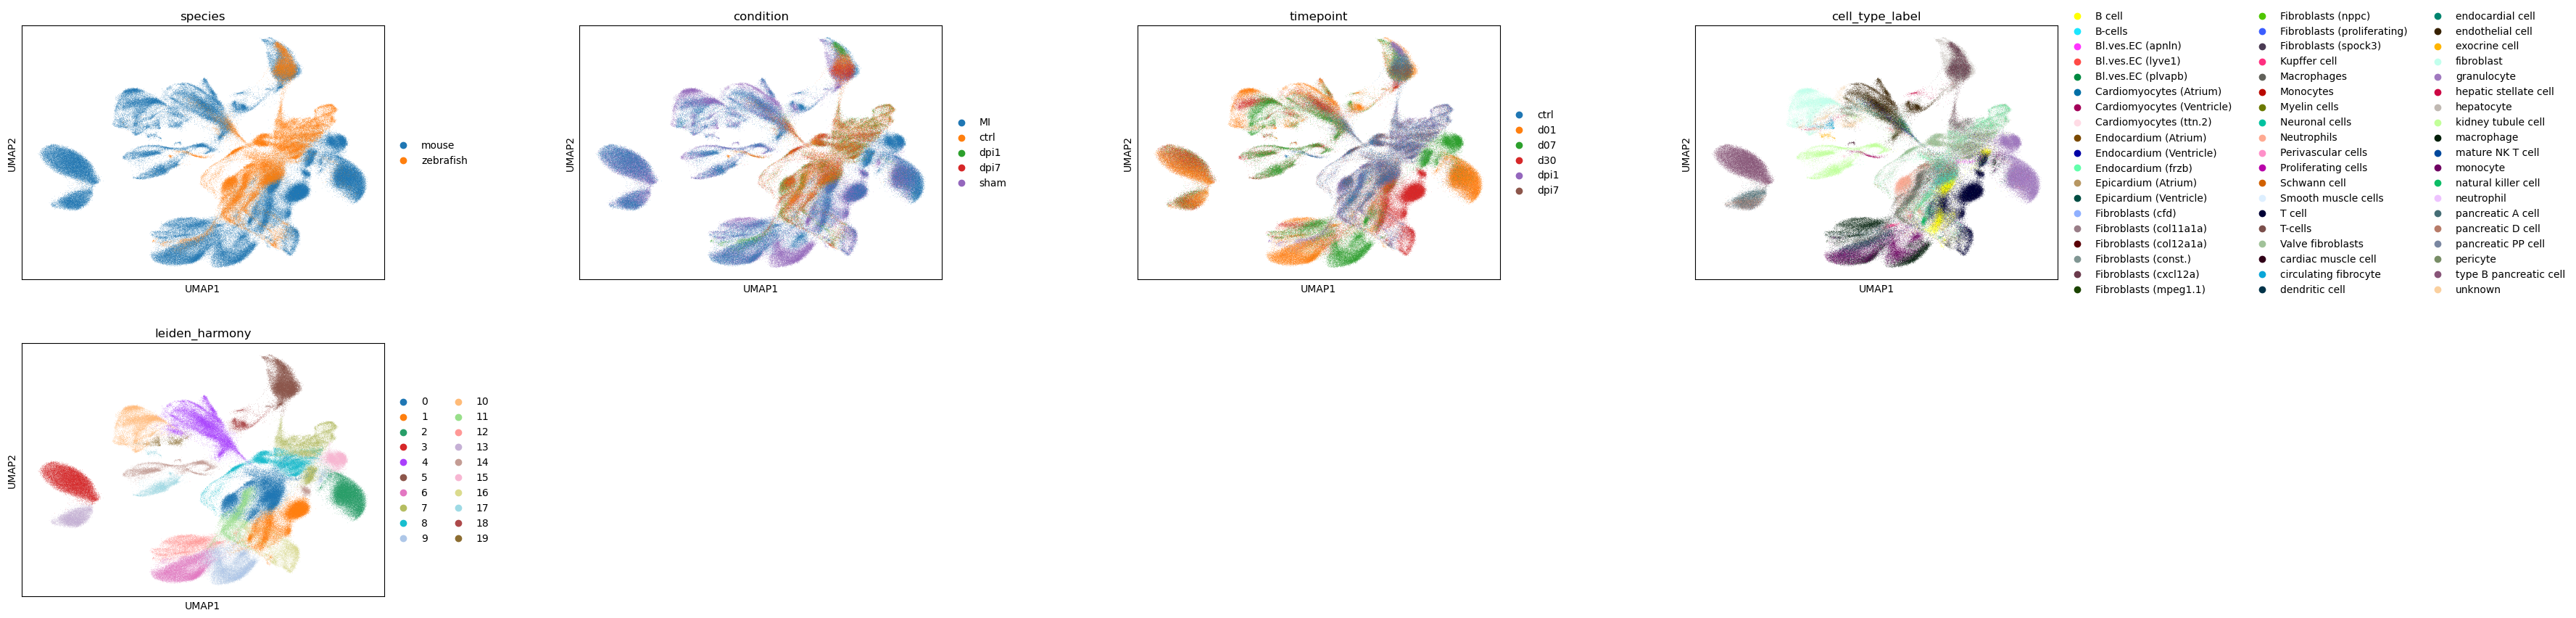

In [85]:
combined_harmony = combined_unintegrated.copy()

# Extract PCA matrix
X_pca = np.asarray(combined_harmony.obsm["X_pca"], dtype=np.float64)

print("Input PCA shape:", X_pca.shape)
print("Expected shape: cells × PCs")
print("Number of cells:", combined_harmony.n_obs)

# Run Harmony 
harmony_out = hm.run_harmony(
    data_mat=X_pca,
    meta_data=combined_harmony.obs,
    vars_use=["species"],
    max_iter_harmony=10,
    random_state=0,
)

# Extract integrated representation
Z_corr = np.asarray(harmony_out.Z_corr)

print("Raw Harmony output shape:", Z_corr.shape)

# Harmonypy versions differ in axis orientation so coerce to cells × PCs
if Z_corr.shape[0] == combined_harmony.n_obs:
    X_harmony = Z_corr
elif Z_corr.shape[1] == combined_harmony.n_obs:
    X_harmony = Z_corr.T
else:
    raise ValueError

print("Final Harmony embedding shape:", X_harmony.shape)

# Store corrected PCs
combined_harmony.obsm["X_pca_harmony"] = X_harmony

sc.pp.neighbors(combined_harmony, n_neighbors=15, use_rep="X_pca_harmony") 
sc.tl.umap(combined_harmony) 
sc.tl.leiden(combined_harmony, resolution=0.6, key_added="leiden_harmony")

sc.pl.umap( 
    combined_harmony, 
    color=[ 
        "species", 
        "condition_harmonised", 
        "timepoint_harmonised", 
        "cell_type_harmonised", 
        "leiden_harmony", 
    ], 
    wspace=0.4 
)


scVI is a deep generative model for single-cell count data which models raw counts directly

/Users/yep25yan/miniforge3/envs/cardiac-integration/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/Users/yep25yan/miniforge3/envs/cardiac-integration/lib/python3.11/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/yep25yan/miniforge3/envs/cardiac-integration/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
💡 Tip: For seamless cloud logging and exper

Epoch 5/5: 100%|███████████████████████| 5/5 [02:03<00:00, 24.49s/it, v_num=1, train_loss=460]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 5/5: 100%|███████████████████████| 5/5 [02:03<00:00, 24.65s/it, v_num=1, train_loss=460]


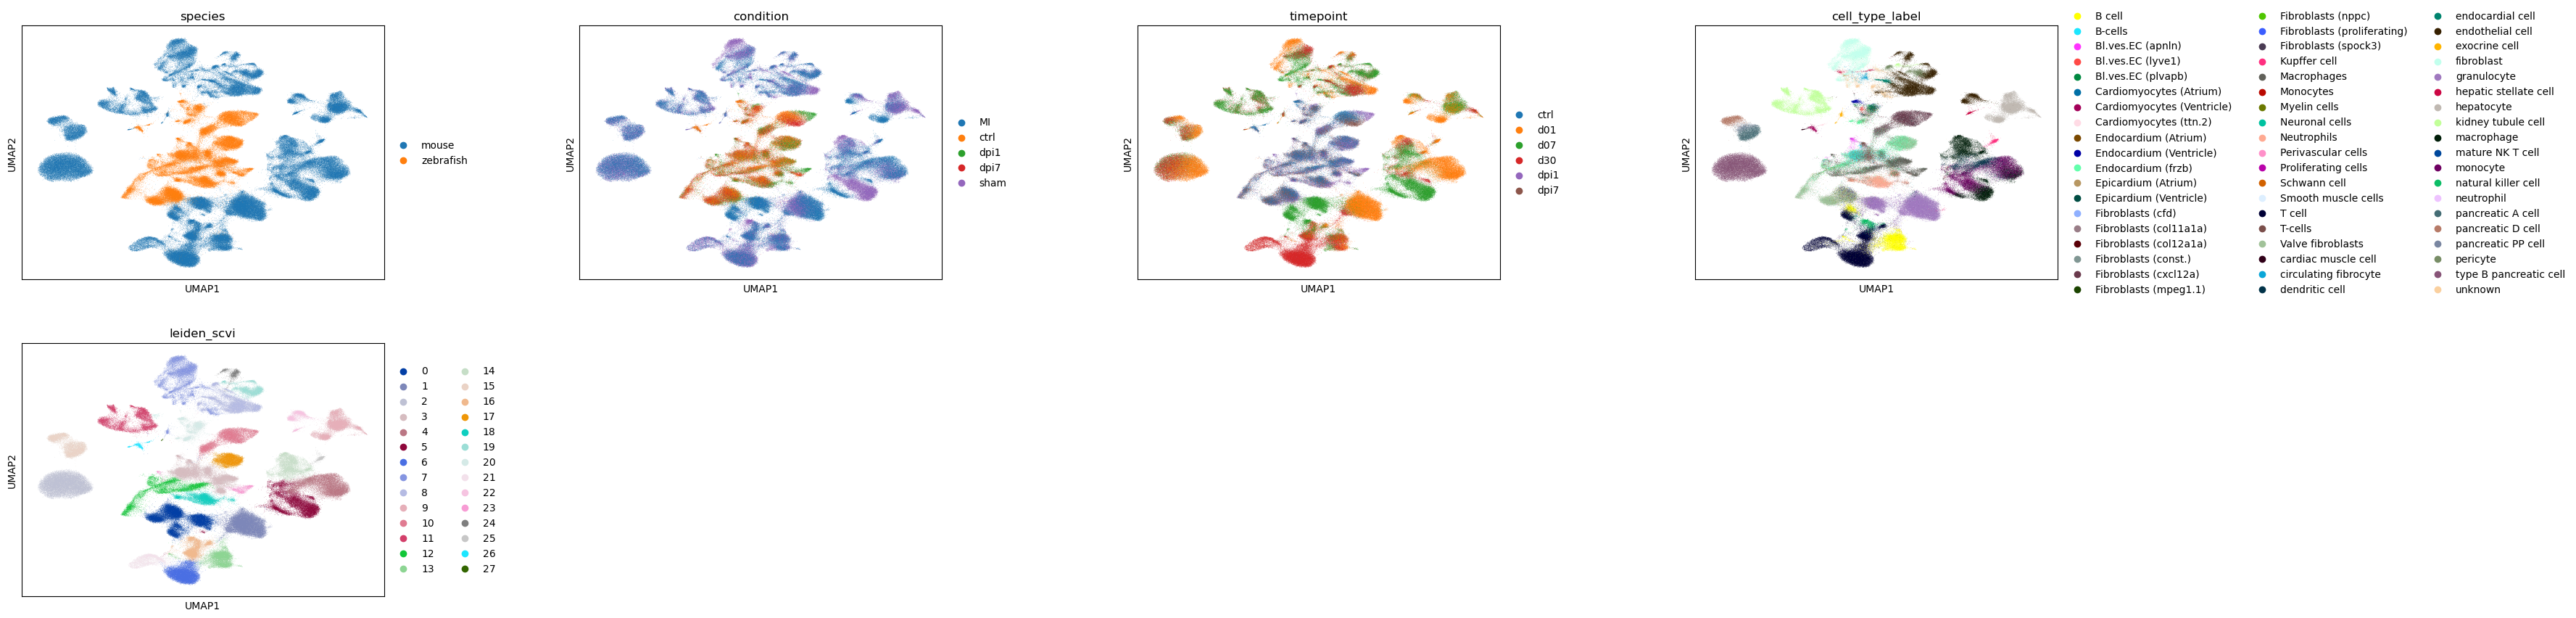

In [89]:
# Use the HVGs selected during joint preprocessing 
hvg_genes = combined_unintegrated.var_names[
    combined_unintegrated.var["highly_variable"]
].tolist()

combined_scvi = combined_unintegrated[:, hvg_genes].copy()

# scVI expects raw counts in the default layer 
combined_scvi.X = combined_scvi.layers["counts"].copy()

# Specify the AnnData object for scVI
scvi.model.SCVI.setup_anndata( 
    combined_scvi, 
    layer="counts", 
    batch_key="species",
)

# Train the model
vae = scvi.model.SCVI( 
    combined_scvi, 
    n_latent=20, 
    n_layers=2, 
    n_hidden=128, 
    gene_likelihood="nb",
) 

vae.train(max_epochs=50)

# Extract the  latent space
combined_scvi.obsm["X_scVI"] = vae.get_latent_representation()

# compute UMAP from latent embeddings
sc.pp.neighbors(combined_scvi, use_rep="X_scVI", n_neighbors=15)
sc.tl.umap(combined_scvi) 
sc.tl.leiden(combined_scvi, resolution=0.6, key_added="leiden_scvi")

sc.pl.umap(
    combined_scvi, 
    color=[
        "species", 
        "condition_harmonised", 
        "timepoint_harmonised", 
        "cell_type_harmonised", 
        "leiden_scvi", 
    ], 
    wspace=0.4,
)

There is no single correct integration result so each method should be validated based on its performance on the data.

KeysView(AxisArrays with keys: X_UMAP, X_pca, X_umap, X_Unintegrated, X_Harmony, X_scVI)
Computing UMAP for Unintegrated
Epoch 1/50:   0%|                                                      | 0/50 [29:37<?, ?it/s]


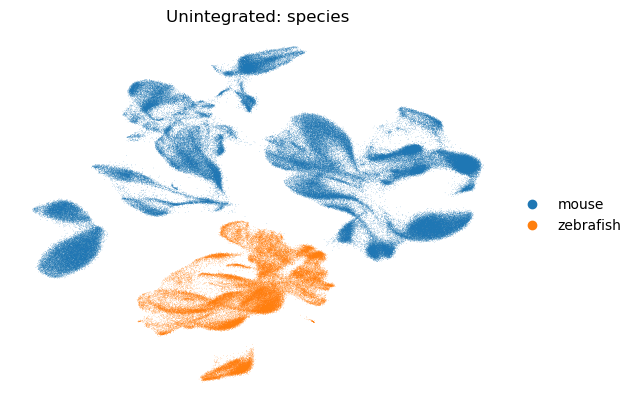

Computing UMAP for Harmony


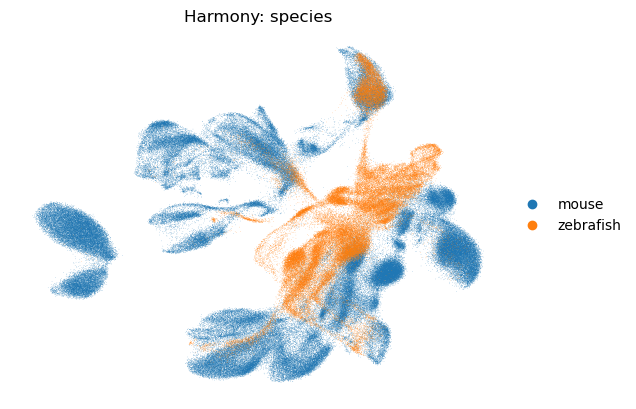

Computing UMAP for scVI


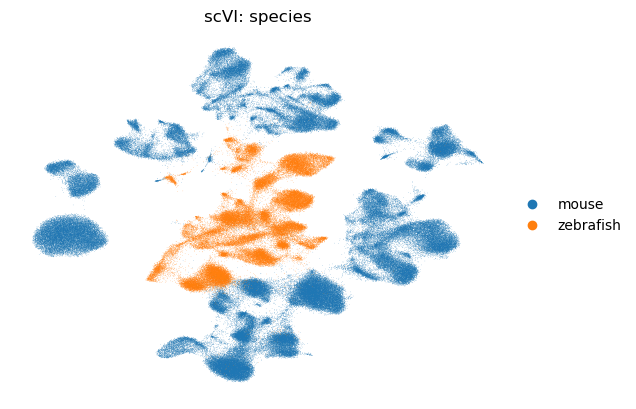

Computing UMAP for Unintegrated


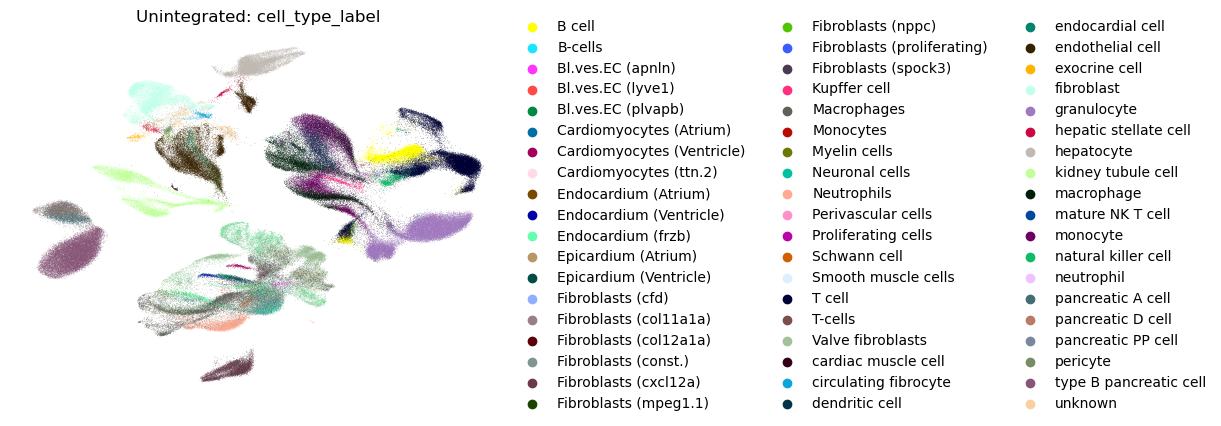

Computing UMAP for Harmony


KeyboardInterrupt: 

In [92]:
# Create one object containing all integration embeddings
combined_methods = combined_unintegrated.copy()
combined_methods.obsm["X_Unintegrated"] = combined_methods.obsm["X_pca"].copy()

# Copy Harmony embedding
combined_methods.obsm["X_Harmony"] = combined_harmony[
    combined_methods.obs_names
].obsm["X_pca_harmony"].copy()

# Copy scVI embedding
combined_methods.obsm["X_scVI"] = combined_scvi[
    combined_methods.obs_names
].obsm["X_scVI"].copy()

print(combined_methods.obsm.keys())

# compare methods side by side

embeddings = {
    "Unintegrated": "X_Unintegrated",
    "Harmony": "X_Harmony",
    "scVI": "X_scVI",
}

for color_by in ["species", "cell_type_harmonised", "condition_harmonised", "timepoint_harmonised"]:
    for method, rep in embeddings.items():
        print(f"Computing UMAP for {method}")
    
        sc.pp.neighbors(
            combined_methods,
            use_rep=rep,
            n_neighbors=15,
            key_added=f"neighbors_{method}",
        )
    
        sc.tl.umap(
            combined_methods,
            neighbors_key=f"neighbors_{method}",
            key_added=f"X_umap_{method}",
        )
    
        sc.pl.embedding(
            combined_methods,
            basis=f"umap_{method}",
            color=color_by,
            title=f"{method}: {color_by}",
            frameon=False,
        )


Quantitative metrics can be used to approximate the quality of integration such based on biological conservation and batch correction

species,mouse,zebrafish
cell_type_label,,
B cell,10541,0
B-cells,0,2615
Bl.ves.EC (apnln),0,576
Bl.ves.EC (lyve1),0,345
Bl.ves.EC (plvapb),0,1538
Cardiomyocytes (Atrium),0,7
Cardiomyocytes (Ventricle),0,485
Cardiomyocytes (ttn.2),0,737
Endocardium (Atrium),0,1257


Number of labels present in at least two species: 0
[]


/Users/yep25yan/miniforge3/envs/cardiac-integration/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Metrics:   0%|        | 0/10 [00:00<?, ?it/s, Bio conservation: nmi_ari_cluster_labels_kmeans]
Metrics:  10%| | 1/10 [00:37<05:40, 37.85s/it, Bio conservation: nmi_ari_cluster_labels_kmeans
Metrics:  30%|███▎       | 3/10 [00:39<01:03,  9.07s/it, Batch correction: graph_connectivity]/Users/yep25yan/miniforge3/envs/cardiac-integration/lib/python3.11/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)

Embeddings:  33%|██

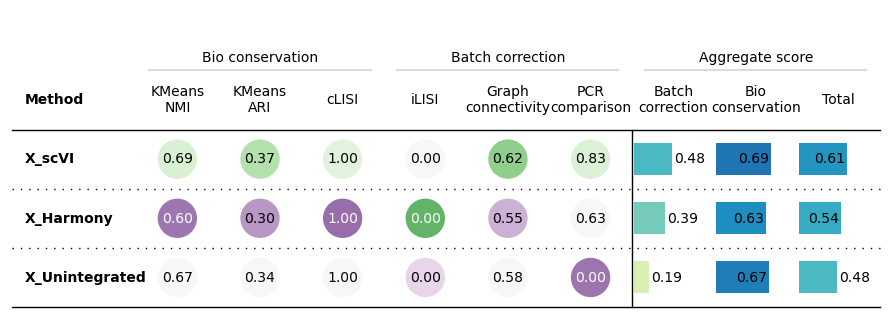

In [103]:
label_species_table = pd.crosstab(
    combined_methods.obs["cell_type_harmonised"],
    combined_methods.obs["species"],
)

display(label_species_table.head(100))

shared_labels = label_species_table.index[
    (label_species_table > 0).sum(axis=1) >= 2
].tolist()

print("Number of labels present in at least two species:", len(shared_labels))
print(shared_labels[:100])


bm = Benchmarker(
    combined_methods,
    batch_key="species",
    label_key="cell_type_harmonised",
    embedding_obsm_keys=embeddings.values(),
     bio_conservation_metrics=BioConservation(
            isolated_labels=False,                
            nmi_ari_cluster_labels_kmeans=True,
            nmi_ari_cluster_labels_leiden=False,    
            silhouette_label=False,               
            clisi_knn=True,
        ),
        batch_correction_metrics=BatchCorrection(
            bras=False,               
            ilisi_knn=True,
            kbet_per_label=False,      
            graph_connectivity=True,
            pcr_comparison=True,
        ),
    n_jobs=-1,
)

bm.benchmark()
bm.plot_results_table()

Pseudobulk samples in order to conduct DEA

In [202]:
# Create pseudobulk group ID
combined.obs["pseudobulk_id"] = (
    combined.obs["sample_id"].astype(str)
    + "__" + combined.obs["species"].astype(str)
    + "__" + combined.obs["cell_type_harmonised"].astype(str)
    + "__" + combined.obs["condition_harmonised"].astype(str)
)

# Sum raw counts per pseudobulk group
pb = sc.get.aggregate(
    combined,
    by="pseudobulk_id",
    func="sum",
    layer="counts",
)

pb.X = pb.layers["sum"].copy()

meta = pb.obs_names.to_series().str.split("__", expand=True)

pb.obs["sample_id"] = meta[0].values
pb.obs["species"] = meta[1].values
pb.obs["cell_type_harmonised"] = meta[2].values
pb.obs["condition_harmonised"] = meta[3].values

# Count how many cells contributed to each pseudobulk sample
n_cells = combined.obs["pseudobulk_id"].value_counts()
pb.obs["n_cells"] = pb.obs_names.map(n_cells).astype(int)

# Filter weak pseudobulked samples
pb = pb[pb.obs["n_cells"] >= 20].copy()

print(pb)

# compute valid comparisons
summary = (
    pb.obs
    .groupby(
        ["species", 
         "condition_harmonised",
         "cell_type_harmonised",
        ],
        observed=True
    )
    .agg(
        n_pseudobulks=("sample_id", "count"),
        n_samples=("sample_id", "nunique"),
        total_cells=("n_cells", "sum"),
    )
    .reset_index()
)

valid = (
    summary
    .groupby([
        "species", 
    ], observed=True
).filter(lambda x: x["condition_harmonised"].nunique() >= 2)
)

display(valid)

AnnData object with n_obs × n_vars = 274 × 1268
    obs: 'pseudobulk_id', 'sample_id', 'species', 'cell_type_harmonised', 'condition_harmonised', 'n_cells'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mouse_symbol', 'ID', 'Symbol', 'zebrafish_symbol', 'mouse_ortholog'
    layers: 'sum'


,species,condition_harmonised,cell_type_harmonised,n_pseudobulks,n_samples,total_cells
0,mouse,control,B cell,5,5,3882
1,mouse,control,Cardiomyocyte,3,3,84
2,mouse,control,Dendritic cell,4,4,1288
3,mouse,control,Endocardial cell,3,3,330
4,mouse,control,Endothelial cell,11,11,7105
5,mouse,control,Fibroblast,4,4,7077
6,mouse,control,Granulocyte / neutrophil,5,5,10708
7,mouse,control,Macrophage,11,11,11145
8,mouse,control,Monocyte,3,3,8375
9,mouse,control,Mural / smooth muscle,5,5,788


Run DEA with PyDESeq2

In [209]:
# Choose comparison to test
label_key = "cell_type_harmonised"
cell_type_to_test = "Other / non-cardiac"

species_to_test = "mouse"

condition_a = "injury"
condition_b = "control"


# Subset pseudobulk object
pb_de = pb[
    (pb.obs["species"].astype(str) == species_to_test)
    & (pb.obs["cell_type_harmonised"].astype(str) == cell_type_to_test)
    & (pb.obs["condition_harmonised"].astype(str).isin([condition_a, condition_b]))
].copy()

print(pb_de)
print(pb_de.obs["condition_harmonised"].value_counts())
display(pb_de.obs[
    ["sample_id", "species", "condition_harmonised", "cell_type_harmonised", "n_cells"]
])

# Stop early if no valid comparison

if pb_de.n_obs == 0:
    raise ValueError(
        "pb_de has 0 pseudobulk samples. "
        "Your species/cell type/timepoint/condition selection does not exist in pb."
    )

if pb_de.obs["condition_harmonised"].nunique() < 2:
    raise ValueError(
        "This subset contains fewer than 2 conditions. "
        "Choose a comparison with both injury and control samples."
    )

replicate_counts = pb_de.obs.groupby("condition_harmonised")["sample_id"].nunique()
print("Replicates per condition:")
print(replicate_counts)

if (replicate_counts < 2).any():
    raise ValueError(
        "Need at least 2 biological samples per condition for a meaningful DEA example."
    )

# Extract counts and metadata 
X = pb_de.layers["sum"]

if sparse.issparse(X):
    X = X.toarray()
else:
    X = np.asarray(X)

counts = pd.DataFrame(
    X,
    index=pb_de.obs_names,
    columns=pb_de.var_names,
)

metadata = pb_de.obs[["condition_harmonised"]].copy()

# Ensure exact index match
metadata = metadata.loc[counts.index]

print("Counts shape:", counts.shape)
print("Metadata shape:", metadata.shape)
print("Indices match:", counts.index.equals(metadata.index))

if not counts.index.equals(metadata.index):
    raise ValueError("counts.index and metadata.index do not match.")

# Remove low-count genes
genes_to_keep = counts.columns[counts.sum(axis=0) >= 10]
counts = counts[genes_to_keep]

print("Final count matrix:", counts.shape)

# Run PyDESeq2
dds = DeseqDataSet(
    counts=counts,
    metadata=metadata,
    design="~ condition_harmonised",
)

dds.deseq2()

stat_res = DeseqStats(
    dds,
    contrast=["condition_harmonised", condition_a, condition_b],
)

stat_res.summary()

de_results = stat_res.results_df.copy()

# Filter for significant DE genes
sig_de = de_results[
    (de_results["padj"] < 0.05)
    & (de_results["log2FoldChange"].abs() > 1)
].copy()

sig_de = sig_de.sort_values(
    ["padj", "log2FoldChange"],
    ascending=[True, False]
)

sig_de

AnnData object with n_obs × n_vars = 16 × 1268
    obs: 'pseudobulk_id', 'sample_id', 'species', 'cell_type_harmonised', 'condition_harmonised', 'n_cells'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mouse_symbol', 'ID', 'Symbol', 'zebrafish_symbol', 'mouse_ortholog'
    layers: 'sum'
condition_harmonised
control    8
injury     8
Name: count, dtype: int64


,sample_id,species,condition_harmonised,cell_type_harmonised,n_cells
mm_donors_A.B__mouse__Other / non-cardiac__control,mm_donors_A.B,mouse,control,Other / non-cardiac,5653
mm_donors_AA__mouse__Other / non-cardiac__injury,mm_donors_AA,mouse,injury,Other / non-cardiac,2497
mm_donors_BB.CC__mouse__Other / non-cardiac__control,mm_donors_BB.CC,mouse,control,Other / non-cardiac,3735
mm_donors_C.D__mouse__Other / non-cardiac__injury,mm_donors_C.D,mouse,injury,Other / non-cardiac,5710
mm_donors_DD__mouse__Other / non-cardiac__injury,mm_donors_DD,mouse,injury,Other / non-cardiac,1961
mm_donors_EE.FF__mouse__Other / non-cardiac__control,mm_donors_EE.FF,mouse,control,Other / non-cardiac,1185
mm_donors_GG.HH__mouse__Other / non-cardiac__injury,mm_donors_GG.HH,mouse,injury,Other / non-cardiac,231
mm_donors_II.JJ__mouse__Other / non-cardiac__control,mm_donors_II.JJ,mouse,control,Other / non-cardiac,3165
mm_donors_KK.LL__mouse__Other / non-cardiac__injury,mm_donors_KK.LL,mouse,injury,Other / non-cardiac,3478
mm_donors_L.M__mouse__Other / non-cardiac__control,mm_donors_L.M,mouse,control,Other / non-cardiac,3596


Replicates per condition:
condition_harmonised
control    8
injury     8
Name: sample_id, dtype: int64
Counts shape: (16, 1268)
Metadata shape: (16, 1)
Indices match: True
Final count matrix: (16, 1239)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.06 seconds.

Fitting dispersion trend curve...
... done in 0.02 seconds.

Fitting MAP dispersions...


Log2 fold change & Wald test p-value: condition_harmonised injury vs control
           baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
Robo1    209.483193        0.259978  0.760108  0.342027  0.732330  0.999438
Btg2    9140.546117        0.136908  0.581256  0.235538  0.813791  0.999438
Hoxb7     34.829510       -0.039641  1.361924 -0.029107  0.976779  0.999438
Psen2   3140.194987       -0.343987  0.873576 -0.393769  0.693752  0.999438
Ccnb1      9.448701        0.422842  0.762343  0.554662  0.579126  0.999438
...             ...             ...       ...       ...       ...       ...
Ran     3691.554023       -0.108260  0.163381 -0.662621  0.507573  0.999438
Cse1l    442.134815       -0.027462  0.241361 -0.113779  0.909413  0.999438
Map3k4   628.808017       -0.102052  0.221273 -0.461206  0.644651  0.999438
Cdc27    366.508547       -0.054590  0.146942 -0.371509  0.710258  0.999438
Ebf2       1.337407       -0.639070  1.146664 -0.557330  0.577302  0.999438

[1239 rows

... done in 0.06 seconds.

Fitting LFCs...
... done in 0.05 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 65 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.05 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
